# ColdMed
## Analyse exploratoire des données de distribution vaccinale et de suivi thermique

### Contexte du projet

ColdMed est un prototype de système intelligent de traçabilité de la chaîne du froid des vaccins et médicaments thermosensibles.

Dans cette première version, le système exploite un dataset de distribution vaccinale avec suivi de température.  
L'objectif est d'étudier la structure des données, d'identifier les variables utiles à la surveillance thermique et de préparer les règles de détection des excursions de température.

### Objectifs de cette première analyse

- Charger et inspecter le fichier de données.
- Vérifier la qualité des données.
- Identifier les colonnes liées à la température, au temps, aux lots et aux expéditions.
- Observer la distribution des mesures disponibles.
- Préparer les futures règles de traçabilité et d'alerte.

## 2. Chargement des données
Import + dimensions

In [ ]:
# Bibliothèques principales pour l'analyse des données
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 100)

Environnement prêt pour l'analyse ColdMed.


In [549]:
# Chemin du fichier Kaggle fourni
import os
is_kaggle = os.path.exists('/kaggle/working')
file_path = '/kaggle/input/coldmed-trace/input_data.csv' if is_kaggle else './data/input_data.csv'

# Vérification de l'existence du fichier
if os.path.exists(file_path):
    print("Fichier trouvé :", file_path)
    print("Taille du fichier :", round(os.path.getsize(file_path) / (1024 * 1024), 2), "MB")
else:
    raise FileNotFoundError(
        "Le fichier n'a pas été trouvé. Vérifie que le dataset est bien ajouté au notebook Kaggle."
    )

# Chargement des données
df = pd.read_csv(file_path)

print("\nChargement réussi.")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

display(df.head())

Fichier trouvé : ./data/input_data.csv
Taille du fichier : 2.64 MB

Chargement réussi.
Nombre de lignes : 26674
Nombre de colonnes : 13


,Unnamed: 0,date,batch_id,location,current_hop,external_storage,thermal_shipper_temp_reading,room_temp_reading,room_humidity_reading,item_expiry_hours,ultra_low_temperature_freezer_hours,out_of_bound_temperature_hours,refrigeration_temperature_hours
0,0,10-07-2020 14:00,batch001,Jharkand,dest_discarded_vaccine_storage_unit,vaccine_storage_unit,14,22,75,-1,720,1,119
1,0,10-07-2020 13:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,4,7,93,0,720,1,119
2,0,10-07-2020 12:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,3,6,93,1,720,1,118
3,0,10-07-2020 11:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,3,8,93,2,720,1,117
4,0,10-07-2020 10:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,4,6,93,3,720,1,116


## 3. Audit qualité initial
Colonnes, missing values, doublons exacts

In [550]:
# Informations générales sur les colonnes
structure_df = pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.astype(str).values,
    "valeurs_non_nulles": df.notna().sum().values,
    "valeurs_manquantes": df.isna().sum().values,
    "pourcentage_manquant": (df.isna().mean() * 100).round(2).values,
    "valeurs_uniques": df.nunique(dropna=True).values
})

display(structure_df)

print("\nTypes de données :")
df.info()

,colonne,type,valeurs_non_nulles,valeurs_manquantes,pourcentage_manquant,valeurs_uniques
0,Unnamed: 0,int64,26674,0,0.0,1
1,date,object,26674,0,0.0,7607
2,batch_id,object,26674,0,0.0,30
3,location,object,26674,0,0.0,12
4,current_hop,object,26674,0,0.0,10
5,external_storage,object,26674,0,0.0,6
6,thermal_shipper_temp_reading,int64,26674,0,0.0,81
7,room_temp_reading,int64,26674,0,0.0,16
8,room_humidity_reading,int64,26674,0,0.0,30
9,item_expiry_hours,int64,26674,0,0.0,842



Types de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26674 entries, 0 to 26673
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Unnamed: 0                           26674 non-null  int64 
 1   date                                 26674 non-null  object
 2   batch_id                             26674 non-null  object
 3   location                             26674 non-null  object
 4   current_hop                          26674 non-null  object
 5   external_storage                     26674 non-null  object
 6   thermal_shipper_temp_reading         26674 non-null  int64 
 7   room_temp_reading                    26674 non-null  int64 
 8   room_humidity_reading                26674 non-null  int64 
 9   item_expiry_hours                    26674 non-null  int64 
 10  ultra_low_temperature_freezer_hours  26674 non-null  int64 
 11  out_of_bound_temperat

In [551]:
# Vérification des doublons
nombre_doublons = df.duplicated().sum()

# Vérification des valeurs manquantes
missing_values = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing_values.columns = ["colonne", "valeurs_manquantes"]
missing_values["pourcentage"] = (
    missing_values["valeurs_manquantes"] / len(df) * 100
).round(2)

print("Nombre de lignes dupliquées :", nombre_doublons)

print("\nColonnes contenant des valeurs manquantes :")
display(missing_values[missing_values["valeurs_manquantes"] > 0])

if nombre_doublons == 0:
    print("Aucun doublon exact détecté.")
else:
    print("Des doublons existent. Nous déciderons ensuite s'ils doivent être supprimés.")

Nombre de lignes dupliquées : 301

Colonnes contenant des valeurs manquantes :


,colonne,valeurs_manquantes,pourcentage


Des doublons existent. Nous déciderons ensuite s'ils doivent être supprimés.


In [552]:
# Séparation des colonnes numériques et textuelles
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
text_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Colonnes numériques :")
print(numeric_columns)

print("\nColonnes textuelles :")
print(text_columns)

if numeric_columns:
    print("\nStatistiques descriptives des variables numériques :")
    display(df[numeric_columns].describe().T)


Colonnes numériques :
['Unnamed: 0', 'thermal_shipper_temp_reading', 'room_temp_reading', 'room_humidity_reading', 'item_expiry_hours', 'ultra_low_temperature_freezer_hours', 'out_of_bound_temperature_hours', 'refrigeration_temperature_hours']

Colonnes textuelles :
['date', 'batch_id', 'location', 'current_hop', 'external_storage']

Statistiques descriptives des variables numériques :


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,26674.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
thermal_shipper_temp_reading,26674.0,-54.023581,28.554758,-71.0,-69.0,-67.0,-65.0,15.0
room_temp_reading,26674.0,0.692847,21.934313,-71.0,6.0,7.0,8.0,25.0
room_humidity_reading,26674.0,91.821774,2.941287,65.0,91.0,92.0,94.0,95.0
item_expiry_hours,26674.0,576.234910,223.664963,-1.0,416.0,629.0,767.0,840.0
ultra_low_temperature_freezer_hours,26674.0,252.859039,220.715960,0.0,52.0,205.0,424.0,720.0
out_of_bound_temperature_hours,26674.0,0.838794,2.000963,0.0,0.0,0.0,0.0,7.0
refrigeration_temperature_hours,26674.0,10.138637,26.014742,0.0,0.0,0.0,0.0,120.0


## 4. Nettoyage
Suppression colonne inutile + correction catégories + dates

In [553]:
# Création d'une copie de travail afin de préserver les données originales
df_clean = df.copy()

# Suppression de la colonne inutile : elle ne contient qu'une seule valeur (0)
if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

# Conservation de la date originale avant transformation
df_clean["date_originale"] = df_clean["date"]

# Correction de quelques catégories mal orthographiées ou incohérentes
df_clean["current_hop_clean"] = df_clean["current_hop"].replace({
    "source_reefer truck": "source_reefer_truck"
})

df_clean["external_storage_clean"] = df_clean["external_storage"].replace({
    "vacccincation_room": "vaccination_room"
})

print("Dimensions avant nettoyage :", df.shape)
print("Dimensions après suppression de la colonne inutile :", df_clean.shape)

display(df_clean.head())

Dimensions avant nettoyage : (26674, 13)
Dimensions après suppression de la colonne inutile : (26674, 15)


,date,batch_id,location,current_hop,external_storage,thermal_shipper_temp_reading,room_temp_reading,room_humidity_reading,item_expiry_hours,ultra_low_temperature_freezer_hours,out_of_bound_temperature_hours,refrigeration_temperature_hours,date_originale,current_hop_clean,external_storage_clean
0,10-07-2020 14:00,batch001,Jharkand,dest_discarded_vaccine_storage_unit,vaccine_storage_unit,14,22,75,-1,720,1,119,10-07-2020 14:00,dest_discarded_vaccine_storage_unit,vaccine_storage_unit
1,10-07-2020 13:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,4,7,93,0,720,1,119,10-07-2020 13:00,dest_vaccine_storage_unit,vaccine_storage_unit
2,10-07-2020 12:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,3,6,93,1,720,1,118,10-07-2020 12:00,dest_vaccine_storage_unit,vaccine_storage_unit
3,10-07-2020 11:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,3,8,93,2,720,1,117,10-07-2020 11:00,dest_vaccine_storage_unit,vaccine_storage_unit
4,10-07-2020 10:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,4,6,93,3,720,1,116,10-07-2020 10:00,dest_vaccine_storage_unit,vaccine_storage_unit


In [554]:
# Conversion des dates en tenant compte de formats mixtes
# Hypothèse de lecture : mois/jour/année lorsque le format est ambigu,
# car certaines dates comme 12/28/2020 ne peuvent pas être lues en jour/mois/année.

df_clean["datetime"] = pd.to_datetime(
    df_clean["date"],
    format="mixed",
    dayfirst=False,
    errors="coerce"
)

# Vérification de la conversion
dates_invalides = df_clean["datetime"].isna().sum()

print("Nombre de dates non converties :", dates_invalides)
print("Date minimale :", df_clean["datetime"].min())
print("Date maximale :", df_clean["datetime"].max())

display(
    df_clean[["date_originale", "datetime"]]
    .drop_duplicates()
    .head(15)
)

# Vérification de la complétude temporelle (après tri)
df_clean = df_clean.sort_values(["batch_id", "datetime"])
print("Tri chronologique effectué avec succès par lot.")


Nombre de dates non converties : 0
Date minimale : 2020-09-01 01:00:00
Date maximale : 2021-08-28 07:00:00


,date_originale,datetime
0,10-07-2020 14:00,2020-10-07 14:00:00
1,10-07-2020 13:00,2020-10-07 13:00:00
2,10-07-2020 12:00,2020-10-07 12:00:00
3,10-07-2020 11:00,2020-10-07 11:00:00
4,10-07-2020 10:00,2020-10-07 10:00:00
5,10-07-2020 09:00,2020-10-07 09:00:00
6,10-07-2020 08:00,2020-10-07 08:00:00
7,10-07-2020 07:00,2020-10-07 07:00:00
8,10-07-2020 06:00,2020-10-07 06:00:00
9,10-07-2020 05:00,2020-10-07 05:00:00


Tri chronologique effectué avec succès par lot.


## 5. Contrôle des lectures multiples
Plusieurs mesures par lot et par heure

In [555]:
# Identification des doublons exacts
duplicate_mask = df_clean.duplicated(keep=False)
duplicates_df = df_clean[duplicate_mask].sort_values(
    by=["batch_id", "datetime"]
)

nombre_doublons_exactes = df_clean.duplicated().sum()

print("Nombre de lignes dupliquées exactes :", nombre_doublons_exactes)
print("Nombre total de lignes impliquées dans des groupes de doublons :", len(duplicates_df))

display(duplicates_df.head(20))


# Suppression des doublons exacts
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("\nDimensions après suppression des doublons :", df_clean.shape)

Nombre de lignes dupliquées exactes : 301
Nombre total de lignes impliquées dans des groupes de doublons : 602


,date,batch_id,location,current_hop,external_storage,thermal_shipper_temp_reading,room_temp_reading,room_humidity_reading,item_expiry_hours,ultra_low_temperature_freezer_hours,out_of_bound_temperature_hours,refrigeration_temperature_hours,date_originale,current_hop_clean,external_storage_clean,datetime
873,09-01-2020 05:00,batch001,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,-69,-70,95,840,0,0,0,09-01-2020 05:00,source_hub,ultra_low_temperature_freezer,2020-09-01 05:00:00
14210,09-01-2020 05:00,batch001,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,-69,-70,95,840,0,0,0,09-01-2020 05:00,source_hub,ultra_low_temperature_freezer,2020-09-01 05:00:00
871,09-01-2020 07:00,batch001,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,-71,-69,95,840,0,0,0,09-01-2020 07:00,source_hub,ultra_low_temperature_freezer,2020-09-01 07:00:00
14208,09-01-2020 07:00,batch001,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,-71,-69,95,840,0,0,0,09-01-2020 07:00,source_hub,ultra_low_temperature_freezer,2020-09-01 07:00:00
858,09-01-2020 20:00,batch001,Not Available,air_transit,ultra_low_temperature_freezer,-69,-69,95,840,0,0,0,09-01-2020 20:00,air_transit,ultra_low_temperature_freezer,2020-09-01 20:00:00
14195,09-01-2020 20:00,batch001,Not Available,air_transit,ultra_low_temperature_freezer,-69,-69,95,840,0,0,0,09-01-2020 20:00,air_transit,ultra_low_temperature_freezer,2020-09-01 20:00:00
853,09-02-2020 01:00,batch001,Not Available,air_transit,ultra_low_temperature_freezer,-69,-70,95,840,0,0,0,09-02-2020 01:00,air_transit,ultra_low_temperature_freezer,2020-09-02 01:00:00
14190,09-02-2020 01:00,batch001,Not Available,air_transit,ultra_low_temperature_freezer,-69,-70,95,840,0,0,0,09-02-2020 01:00,air_transit,ultra_low_temperature_freezer,2020-09-02 01:00:00
713,09-07-2020 21:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,-70,6,93,712,128,0,0,09-07-2020 21:00,dest_vaccine_storage_unit,vaccine_storage_unit,2020-09-07 21:00:00
14050,09-07-2020 21:00,batch001,Jharkand,dest_vaccine_storage_unit,vaccine_storage_unit,-70,6,93,712,128,0,0,09-07-2020 21:00,dest_vaccine_storage_unit,vaccine_storage_unit,2020-09-07 21:00:00



Dimensions après suppression des doublons : (26373, 16)


In [556]:
# Contrôle des lectures multiples pour un même lot et une même heure

multi_readings = (
    df_clean
    .groupby(["batch_id", "datetime"])
    .agg(
        nombre_lectures=("thermal_shipper_temp_reading", "size"),
        temperature_min=("thermal_shipper_temp_reading", "min"),
        temperature_max=("thermal_shipper_temp_reading", "max"),
        nombre_temperatures_distinctes=("thermal_shipper_temp_reading", "nunique"),
        nombre_stockages_distincts=("external_storage_clean", "nunique"),
        nombre_etapes_distinctes=("current_hop_clean", "nunique")
    )
    .reset_index()
)

multi_readings_detectees = multi_readings[
    multi_readings["nombre_lectures"] > 1
]

multi_readings_temperature_differente = multi_readings_detectees[
    multi_readings_detectees["nombre_temperatures_distinctes"] > 1
]

print("Groupes lot/date avec plusieurs lectures :", len(multi_readings_detectees))
print(
    "Groupes lot/date avec plusieurs températures différentes :",
    len(multi_readings_temperature_differente)
)

display(multi_readings_temperature_differente.head(10))

Groupes lot/date avec plusieurs lectures : 13036
Groupes lot/date avec plusieurs températures différentes : 10535


,batch_id,datetime,nombre_lectures,temperature_min,temperature_max,nombre_temperatures_distinctes,nombre_stockages_distincts,nombre_etapes_distinctes
0,batch001,2020-09-01 01:00:00,2,-71,-69,2,1,1
1,batch001,2020-09-01 02:00:00,2,-71,-69,2,1,1
2,batch001,2020-09-01 03:00:00,2,-71,-70,2,1,1
3,batch001,2020-09-01 04:00:00,2,-71,-69,2,1,1
5,batch001,2020-09-01 06:00:00,2,-70,-69,2,1,1
8,batch001,2020-09-01 09:00:00,2,-71,-69,2,1,1
9,batch001,2020-09-01 10:00:00,2,-70,-69,2,1,1
10,batch001,2020-09-01 11:00:00,2,-71,-70,2,1,1
11,batch001,2020-09-01 12:00:00,2,-71,-70,2,1,1
12,batch001,2020-09-01 13:00:00,2,-70,-69,2,1,1


### Contrôle des lectures multiples

Après suppression des doublons exacts, plusieurs mesures peuvent encore exister pour un même lot à la même heure.

Ces lignes ne doivent pas être supprimées automatiquement, car elles présentent parfois des températures différentes.  
Le dataset ne contient pas d'identifiant de capteur permettant de savoir si ces lectures proviennent de plusieurs dispositifs ou d'une répétition de mesure.

Pour le tableau de bord, les données seront donc agrégées par lot et par heure :

- température minimale observée ;
- température maximale observée ;
- température moyenne observée ;
- nombre de lectures disponibles.

La température maximale sera utilisée comme signal de vigilance dans l'analyse qualité.

## 6. Agrégation horaire
Min, max, moyenne des températures par lot/heure

In [557]:
# Agrégation horaire des mesures

hourly_data = (
    df_clean
    .groupby(["batch_id", "datetime"], as_index=False)
    .agg(
        location=("location", "first"),
        current_hop_clean=("current_hop_clean", "first"),
        external_storage_clean=("external_storage_clean", "first"),
        nombre_lectures=("thermal_shipper_temp_reading", "size"),
        temperature_min=("thermal_shipper_temp_reading", "min"),
        temperature_max=("thermal_shipper_temp_reading", "max"),
        temperature_moyenne=("thermal_shipper_temp_reading", "mean"),
        humidite_moyenne=("room_humidity_reading", "mean"),
        item_expiry_hours_min=("item_expiry_hours", "min"),
        ultra_low_temperature_freezer_hours_max=("ultra_low_temperature_freezer_hours", "max"),
        out_of_bound_temperature_hours_max=("out_of_bound_temperature_hours", "max"),
        refrigeration_temperature_hours_max=("refrigeration_temperature_hours", "max")
    )
)

hourly_data["temperature_moyenne"] = hourly_data["temperature_moyenne"].round(2)
hourly_data["humidite_moyenne"] = hourly_data["humidite_moyenne"].round(2)

print("Nombre de lignes avant agrégation horaire :", len(df_clean))
print("Nombre de lignes après agrégation horaire :", len(hourly_data))

display(hourly_data.head())

Nombre de lignes avant agrégation horaire : 26373
Nombre de lignes après agrégation horaire : 13337


,batch_id,datetime,location,current_hop_clean,external_storage_clean,nombre_lectures,temperature_min,temperature_max,temperature_moyenne,humidite_moyenne,item_expiry_hours_min,ultra_low_temperature_freezer_hours_max,out_of_bound_temperature_hours_max,refrigeration_temperature_hours_max
0,batch001,2020-09-01 01:00:00,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,2,-71,-69,-70.0,95.0,840,0,0,0
1,batch001,2020-09-01 02:00:00,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,2,-71,-69,-70.0,95.0,840,0,0,0
2,batch001,2020-09-01 03:00:00,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,2,-71,-70,-70.5,95.0,840,0,0,0
3,batch001,2020-09-01 04:00:00,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,2,-71,-69,-70.0,95.0,840,0,0,0
4,batch001,2020-09-01 05:00:00,"Kalamazoo, Michigan",source_hub,ultra_low_temperature_freezer,1,-69,-69,-69.0,95.0,840,0,0,0


## 7. Lecture logistique
Étapes et environnements

In [558]:
# Répartition des observations par étape logistique
hop_distribution = (
    df_clean["current_hop_clean"]
    .value_counts()
    .rename_axis("etape_logistique")
    .reset_index(name="nombre_observations")
)

# Répartition des observations par environnement de stockage
storage_distribution = (
    df_clean["external_storage_clean"]
    .value_counts()
    .rename_axis("environnement_stockage")
    .reset_index(name="nombre_observations")
)

print("Répartition par étape logistique :")
display(hop_distribution)

print("Répartition par environnement de stockage :")
display(storage_distribution)

# Croisement entre étape logistique et environnement de stockage
hop_storage_cross = pd.crosstab(
    df_clean["current_hop_clean"],
    df_clean["external_storage_clean"]
)

print("Croisement entre étape logistique et stockage :")
display(hop_storage_cross)

Répartition par étape logistique :


,etape_logistique,nombre_observations
0,dest_vaccine_storage_unit,21232
1,dest_air_cargo,1761
2,dest_reefer_truck,1275
3,air_transit,1119
4,source_hub,559
5,source_air_cargo,173
6,immunization_site,120
7,source_reefer_truck,60
8,last_mile,40
9,dest_discarded_vaccine_storage_unit,34


Répartition par environnement de stockage :


,environnement_stockage,nombre_observations
0,vaccine_storage_unit,22702
1,ultra_low_temperature_freezer,2197
2,reefer_truck,1275
3,vaccination_room,120
4,local_transport,40
5,discarded_vaccine_storage_unit,39


Croisement entre étape logistique et stockage :


external_storage_clean,discarded_vaccine_storage_unit,local_transport,reefer_truck,ultra_low_temperature_freezer,vaccination_room,vaccine_storage_unit
current_hop_clean,,,,,,
air_transit,0,0,0,1119,0,0
dest_air_cargo,0,0,0,286,0,1475
dest_discarded_vaccine_storage_unit,33,0,0,0,0,1
dest_reefer_truck,0,0,1275,0,0,0
dest_vaccine_storage_unit,6,0,0,0,0,21226
immunization_site,0,0,0,0,120,0
last_mile,0,40,0,0,0,0
source_air_cargo,0,0,0,173,0,0
source_hub,0,0,0,559,0,0


## 8. Régimes thermiques
Ultra-low / réfrigéré / température élevée

In [559]:
# Statistiques de température par environnement de stockage
temperature_by_storage = (
    df_clean
    .groupby("external_storage_clean")["thermal_shipper_temp_reading"]
    .agg(
        nombre_mesures="count",
        temperature_min="min",
        temperature_moyenne="mean",
        temperature_mediane="median",
        temperature_max="max"
    )
    .round(2)
    .reset_index()
    .sort_values(by="temperature_moyenne")
)

display(temperature_by_storage)

# Statistiques de température par étape logistique
temperature_by_hop = (
    df_clean
    .groupby("current_hop_clean")["thermal_shipper_temp_reading"]
    .agg(
        nombre_mesures="count",
        temperature_min="min",
        temperature_moyenne="mean",
        temperature_mediane="median",
        temperature_max="max"
    )
    .round(2)
    .reset_index()
    .sort_values(by="temperature_moyenne")
)

display(temperature_by_hop)

,external_storage_clean,nombre_mesures,temperature_min,temperature_moyenne,temperature_mediane,temperature_max
3,ultra_low_temperature_freezer,2197,-71,-69.58,-70.0,-33
5,vaccine_storage_unit,22702,-70,-54.36,-67.0,14
2,reefer_truck,1275,-70,-29.27,3.0,8
1,local_transport,40,2,2.90,3.0,4
4,vaccination_room,120,2,2.90,3.0,4
0,discarded_vaccine_storage_unit,39,2,10.28,12.0,15


,current_hop_clean,nombre_mesures,temperature_min,temperature_moyenne,temperature_mediane,temperature_max
8,source_hub,559,-71,-70.03,-70.0,-69
7,source_air_cargo,173,-71,-70.02,-70.0,-69
9,source_reefer_truck,60,-71,-70.02,-70.0,-69
0,air_transit,1119,-71,-69.60,-70.0,-33
4,dest_vaccine_storage_unit,21232,-70,-58.34,-67.0,15
3,dest_reefer_truck,1275,-70,-29.27,3.0,8
1,dest_air_cargo,1761,-71,-8.44,7.0,8
5,immunization_site,120,2,2.90,3.0,4
6,last_mile,40,2,2.90,3.0,4
2,dest_discarded_vaccine_storage_unit,34,2,9.97,12.0,15


In [560]:
# Création de catégories descriptives de température
temperature = df_clean["thermal_shipper_temp_reading"]

conditions = [
    temperature.between(-90, -60, inclusive="both"),
    temperature.between(2, 8, inclusive="both"),
    temperature > 8,
    temperature.between(-59, 1, inclusive="both"),
    temperature < -90
]

labels = [
    "Ultra-basse température observée (-90°C à -60°C)",
    "Réfrigération observée (2°C à 8°C)",
    "Température supérieure à 8°C",
    "Zone intermédiaire à vérifier (-59°C à 1°C)",
    "Température inférieure à -90°C"
]

df_clean["zone_thermique_observee"] = np.select(
    conditions,
    labels,
    default="Non classée"
)

zone_distribution = (
    df_clean["zone_thermique_observee"]
    .value_counts()
    .rename_axis("zone_thermique_observee")
    .reset_index(name="nombre_observations")
)

display(zone_distribution)

,zone_thermique_observee,nombre_observations
0,Ultra-basse température observée (-90°C à -60°C),21332
1,Réfrigération observée (2°C à 8°C),4802
2,Zone intermédiaire à vérifier (-59°C à 1°C),207
3,Température supérieure à 8°C,32


In [561]:
# Signaux directement issus du dataset
df_clean["signal_temperature_hors_limite"] = (
    df_clean["out_of_bound_temperature_hours"] > 0
)

df_clean["signal_expiration_atteinte"] = (
    df_clean["item_expiry_hours"] < 0
)

df_clean["signal_vaccin_discarded"] = (
    df_clean["current_hop_clean"] == "dest_discarded_vaccine_storage_unit"
)

incident_summary = pd.DataFrame({
    "indicateur": [
        "Observations avec heures hors limite",
        "Observations avec expiration atteinte",
        "Observations dans l'étape discarded vaccine"
    ],
    "nombre_observations": [
        int(df_clean["signal_temperature_hors_limite"].sum()),
        int(df_clean["signal_expiration_atteinte"].sum()),
        int(df_clean["signal_vaccin_discarded"].sum())
    ]
})

incident_summary["pourcentage"] = (
    incident_summary["nombre_observations"] / len(df_clean) * 100
).round(2)

display(incident_summary)

,indicateur,nombre_observations,pourcentage
0,Observations avec heures hors limite,5043,19.12
1,Observations avec expiration atteinte,10,0.04
2,Observations dans l'étape discarded vaccine,34,0.13


## 9. Résumé par lot
Température max, heures hors limite, expiration

In [562]:
# Résumé des informations par lot vaccinal
batch_summary = (
    df_clean
    .groupby("batch_id")
    .agg(
        premiere_mesure=("datetime", "min"),
        derniere_mesure=("datetime", "max"),
        nombre_mesures=("batch_id", "size"),
        nombre_localisations=("location", "nunique"),
        temperature_min=("thermal_shipper_temp_reading", "min"),
        temperature_max=("thermal_shipper_temp_reading", "max"),
        temperature_moyenne=("thermal_shipper_temp_reading", "mean"),
        humidite_moyenne=("room_humidity_reading", "mean"),
        heures_hors_limite_max=("out_of_bound_temperature_hours", "max"),
        heures_refrigeration_max=("refrigeration_temperature_hours", "max"),
        heures_ultra_low_max=("ultra_low_temperature_freezer_hours", "max"),
        expiration_min=("item_expiry_hours", "min"),
        presence_discarded=("signal_vaccin_discarded", "max")
    )
    .reset_index()
)

batch_summary["temperature_moyenne"] = batch_summary["temperature_moyenne"].round(2)
batch_summary["humidite_moyenne"] = batch_summary["humidite_moyenne"].round(2)

# Création d'un statut analytique basé uniquement sur les signaux présents dans les données
batch_summary["statut_analytique"] = np.select(
    [
        batch_summary["presence_discarded"] == True,
        batch_summary["expiration_min"] < 0,
        batch_summary["heures_hors_limite_max"] > 0
    ],
    [
        "Lot dirigé vers stockage de vaccins écartés",
        "Expiration atteinte dans les observations",
        "Signal de température hors limite détecté"
    ],
    default="Aucun incident signalé dans les variables disponibles"
)

batch_summary = batch_summary.sort_values(
    by=["presence_discarded", "heures_hors_limite_max", "temperature_max"],
    ascending=[False, False, False]
)

display(batch_summary)

,batch_id,premiere_mesure,derniere_mesure,nombre_mesures,nombre_localisations,temperature_min,temperature_max,temperature_moyenne,humidite_moyenne,heures_hors_limite_max,heures_refrigeration_max,heures_ultra_low_max,expiration_min,presence_discarded,statut_analytique
6,batch007,2021-03-01 01:00:00,2021-03-07 10:00:00,306,5,-71,15,-10.42,89.22,7,114,0,721,True,Lot dirigé vers stockage de vaccins écartés
28,batch029,2021-08-01 01:00:00,2021-08-07 10:00:00,306,5,-71,14,-10.41,89.32,7,114,0,721,True,Lot dirigé vers stockage de vaccins écartés
12,batch013,2020-11-01 01:00:00,2020-11-07 10:00:00,305,5,-71,10,-10.37,89.24,7,114,0,721,True,Lot dirigé vers stockage de vaccins écartés
15,batch016,2021-02-01 01:00:00,2021-02-07 14:00:00,306,5,-71,14,-10.59,89.37,6,114,1,719,True,Lot dirigé vers stockage de vaccins écartés
16,batch017,2021-03-01 01:00:00,2021-03-12 22:00:00,566,7,-71,14,-36.96,90.50,6,114,124,595,True,Lot dirigé vers stockage de vaccins écartés
26,batch027,2021-06-01 01:00:00,2021-06-07 19:00:00,321,6,-71,14,-16.02,89.49,6,108,8,718,True,Lot dirigé vers stockage de vaccins écartés
3,batch004,2020-12-01 01:00:00,2020-12-07 14:00:00,312,5,-71,13,-11.80,89.56,6,114,1,719,True,Lot dirigé vers stockage de vaccins écartés
4,batch005,2021-01-01 01:00:00,2021-01-07 19:00:00,321,6,-71,13,-16.61,89.50,6,108,7,718,True,Lot dirigé vers stockage de vaccins écartés
24,batch025,2021-07-01 01:00:00,2021-07-12 22:00:00,562,7,-71,13,-37.41,90.43,6,114,124,595,True,Lot dirigé vers stockage de vaccins écartés
14,batch015,2021-03-01 01:00:00,2021-03-07 19:00:00,320,6,-71,12,-16.36,89.68,6,108,7,718,True,Lot dirigé vers stockage de vaccins écartés


## 10. Issue finale observée
Livré / écart explicite / discordance à valider

In [563]:
# Dernier état horaire observé pour chaque lot

final_state = (
    hourly_data
    .sort_values(["batch_id", "datetime"])
    .groupby("batch_id", as_index=False)
    .tail(1)
    .rename(columns={
        "datetime": "date_fin_observee",
        "location": "localisation_finale",
        "current_hop_clean": "etape_finale",
        "external_storage_clean": "stockage_final",
        "temperature_min": "temperature_finale_min",
        "temperature_max": "temperature_finale_max",
        "temperature_moyenne": "temperature_finale_moyenne",
        "item_expiry_hours_min": "expiration_heures_finale",
        "out_of_bound_temperature_hours_max": "heures_hors_limite_finales"
    })
)

display(final_state.sort_values("batch_id"))

,batch_id,date_fin_observee,localisation_finale,etape_finale,stockage_final,nombre_lectures,temperature_finale_min,temperature_finale_max,temperature_finale_moyenne,humidite_moyenne,expiration_heures_finale,ultra_low_temperature_freezer_hours_max,heures_hors_limite_finales,refrigeration_temperature_hours_max
877,batch001,2020-10-07 14:00:00,Jharkand,dest_discarded_vaccine_storage_unit,vaccine_storage_unit,2,13,14,13.5,79.5,-1,720,1,119
1172,batch002,2020-10-13 07:00:00,Pune,immunization_site,vaccination_room,2,2,4,3.0,67.5,586,240,1,13
1458,batch003,2020-11-12 22:00:00,Chattisgarh,dest_discarded_vaccine_storage_unit,discarded_vaccine_storage_unit,2,10,10,10.0,76.5,595,124,6,114
1616,batch004,2020-12-07 14:00:00,Delhi Airport,dest_discarded_vaccine_storage_unit,discarded_vaccine_storage_unit,2,10,13,11.5,83.0,719,1,6,114
1779,batch005,2021-01-07 19:00:00,Delhi-Chattisgarh,dest_discarded_vaccine_storage_unit,discarded_vaccine_storage_unit,2,12,13,12.5,80.0,718,7,6,108
2417,batch006,2021-02-27 14:00:00,Jharkand,dest_vaccine_storage_unit,discarded_vaccine_storage_unit,2,13,15,14.0,81.5,239,480,6,114
2571,batch007,2021-03-07 10:00:00,Delhi Airport,dest_discarded_vaccine_storage_unit,discarded_vaccine_storage_unit,2,12,15,13.5,77.5,721,0,7,114
3449,batch008,2021-05-07 14:00:00,Jharkand,dest_discarded_vaccine_storage_unit,discarded_vaccine_storage_unit,2,2,3,2.5,91.0,-1,720,1,120
3864,batch009,2021-05-18 07:00:00,Pune,immunization_site,vaccination_room,2,2,3,2.5,68.0,466,360,1,13
4159,batch010,2021-06-13 07:00:00,Pune,immunization_site,vaccination_room,2,2,3,2.5,69.5,586,240,1,13


In [564]:
# Classification de l'issue finale observée

def definir_issue_finale(row):
    if row["etape_finale"] == "immunization_site":
        return "Livré au site de vaccination"
    
    elif row["etape_finale"] == "dest_discarded_vaccine_storage_unit":
        return "Écart explicite observé"
    
    elif row["stockage_final"] == "discarded_vaccine_storage_unit":
        return "Discordance à valider"
    
    else:
        return "Parcours à examiner"

final_state["issue_finale_observee"] = final_state.apply(
    definir_issue_finale,
    axis=1
)

display(
    final_state["issue_finale_observee"]
    .value_counts()
    .rename_axis("issue_finale_observee")
    .reset_index(name="nombre_lots")
)

,issue_finale_observee,nombre_lots
0,Écart explicite observé,17
1,Livré au site de vaccination,10
2,Discordance à valider,3


In [565]:
# Fusion entre le résumé analytique par lot et le dernier état horaire observé

batch_dashboard = batch_summary.merge(
    final_state[[
        "batch_id",
        "date_fin_observee",
        "localisation_finale",
        "etape_finale",
        "stockage_final",
        "temperature_finale_min",
        "temperature_finale_max",
        "temperature_finale_moyenne",
        "expiration_heures_finale",
        "heures_hors_limite_finales",
        "issue_finale_observee"
    ]],
    on="batch_id",
    how="left"
)

# Signaux analytiques supplémentaires fondés sur l'ensemble du parcours du lot
batch_dashboard["signal_temperature_superieure_8"] = (
    batch_dashboard["temperature_max"] > 8
)

batch_dashboard["signal_excursion_prolongee"] = (
    batch_dashboard["heures_hors_limite_max"] >= 5
)

batch_dashboard["signal_expiration"] = (
    batch_dashboard["expiration_min"] < 0
)

# Signal spécifique à la dernière heure observée
batch_dashboard["signal_temperature_finale_superieure_8"] = (
    batch_dashboard["temperature_finale_max"] > 8
)

# Affichage de contrôle
display(
    batch_dashboard[[
        "batch_id",
        "temperature_min",
        "temperature_max",
        "heures_hors_limite_max",
        "expiration_min",
        "temperature_finale_min",
        "temperature_finale_max",
        "temperature_finale_moyenne",
        "issue_finale_observee",
        "signal_temperature_superieure_8",
        "signal_excursion_prolongee",
        "signal_expiration"
    ]].sort_values(
        by=["issue_finale_observee", "heures_hors_limite_max", "temperature_max"],
        ascending=[True, False, False]
    )
)

,batch_id,temperature_min,temperature_max,heures_hors_limite_max,expiration_min,temperature_finale_min,temperature_finale_max,temperature_finale_moyenne,issue_finale_observee,signal_temperature_superieure_8,signal_excursion_prolongee,signal_expiration
17,batch006,-71,15,6,239,13,15,14.0,Discordance à valider,True,True,False
18,batch014,-71,13,6,239,9,13,11.0,Discordance à valider,True,True,False
19,batch028,-71,13,6,239,13,13,13.0,Discordance à valider,True,True,False
20,batch002,-71,4,1,586,2,4,3.0,Livré au site de vaccination,False,False,False
21,batch009,-71,4,1,466,2,3,2.5,Livré au site de vaccination,False,False,False
22,batch010,-71,4,1,586,2,3,2.5,Livré au site de vaccination,False,False,False
23,batch011,-71,4,1,466,2,3,2.5,Livré au site de vaccination,False,False,False
24,batch018,-71,4,1,346,3,4,3.5,Livré au site de vaccination,False,False,False
25,batch020,-71,4,1,346,4,4,4.0,Livré au site de vaccination,False,False,False
26,batch021,-71,4,1,226,3,4,3.5,Livré au site de vaccination,False,False,False


## 11. Priorisation qualité
Critique / élevée / surveillance

In [566]:
# Niveau de revue qualité : outil d'aide à la priorisation
# Ce niveau n'est pas une décision officielle de écart explicite observé.

def definir_niveau_revue(row):
    if row["issue_finale_observee"] == "Discordance à valider":
        return "Priorité critique - discordance à valider"
    
    elif row["signal_expiration"]:
        return "Priorité critique - expiration observée"
    
    elif (
        row["signal_excursion_prolongee"]
        and row["signal_temperature_superieure_8"]
    ):
        return "Priorité élevée - excursion thermique prolongée"
    
    elif row["heures_hors_limite_max"] > 0:
        return "Surveillance - signal thermique enregistré"
    
    else:
        return "Aucun signal identifié"

batch_dashboard["niveau_revue_qualite"] = batch_dashboard.apply(
    definir_niveau_revue,
    axis=1
)

review_distribution = (
    batch_dashboard["niveau_revue_qualite"]
    .value_counts()
    .rename_axis("niveau_revue_qualite")
    .reset_index(name="nombre_lots")
)

display(review_distribution)

,niveau_revue_qualite,nombre_lots
0,Priorité élevée - excursion thermique prolongée,12
1,Surveillance - signal thermique enregistré,10
2,Priorité critique - expiration observée,5
3,Priorité critique - discordance à valider,3


In [567]:
# KPIs finaux plus pertinents pour l'application ColdMed Trace
kpis_dashboard = pd.DataFrame({
    "KPI": [
        "Nombre total de lots analysés",
        "Lots livrés au site de vaccination",
        "Lots avec écart explicite observé",
        "Lots avec discordance à valider",
        "Lots avec expiration observée",
        "Lots avec durée hors limite >= 5 h",
        "Lots avec température maximale > 8°C"
    ],
    "Valeur": [
        batch_dashboard["batch_id"].nunique(),
        (batch_dashboard["issue_finale_observee"] == "Livré au site de vaccination").sum(),
        (batch_dashboard["issue_finale_observee"] == "Écart explicite observé").sum(),
        (batch_dashboard["issue_finale_observee"] == "Discordance à valider").sum(),
        batch_dashboard["signal_expiration"].sum(),
        batch_dashboard["signal_excursion_prolongee"].sum(),
        batch_dashboard["signal_temperature_superieure_8"].sum()
    ]
})

display(kpis_dashboard)

,KPI,Valeur
0,Nombre total de lots analysés,30
1,Lots livrés au site de vaccination,10
2,Lots avec écart explicite observé,17
3,Lots avec discordance à valider,3
4,Lots avec expiration observée,5
5,Lots avec durée hors limite >= 5 h,15
6,Lots avec température maximale > 8°C,16


In [568]:
# Tableau comparatif entre issue finale et signaux observés
comparison_table = (
    batch_dashboard
    .groupby("issue_finale_observee")
    .agg(
        nombre_lots=("batch_id", "count"),
        lots_expiration_observee=("signal_expiration", "sum"),
        lots_temperature_superieure_8=("signal_temperature_superieure_8", "sum"),
        lots_excursion_prolongee=("signal_excursion_prolongee", "sum"),
        temperature_max_moyenne=("temperature_max", "mean"),
        heures_hors_limite_moyennes=("heures_hors_limite_max", "mean")
    )
    .round(2)
    .reset_index()
)

display(comparison_table)

,issue_finale_observee,nombre_lots,lots_expiration_observee,lots_temperature_superieure_8,lots_excursion_prolongee,temperature_max_moyenne,heures_hors_limite_moyennes
0,Discordance à valider,3,0,3,3,13.67,6.00
1,Livré au site de vaccination,10,0,0,0,4.00,1.00
2,Écart explicite observé,17,5,13,12,10.88,4.65


In [569]:
# Lots dont la fin de parcours nécessite une validation qualité

lots_a_valider = batch_dashboard[
    batch_dashboard["issue_finale_observee"] == "Discordance à valider"
][[
    "batch_id",
    "date_fin_observee",
    "localisation_finale",
    "etape_finale",
    "stockage_final",
    "temperature_max",
    "temperature_finale_min",
    "temperature_finale_max",
    "heures_hors_limite_max",
    "expiration_min",
    "niveau_revue_qualite"
]]

display(lots_a_valider)

,batch_id,date_fin_observee,localisation_finale,etape_finale,stockage_final,temperature_max,temperature_finale_min,temperature_finale_max,heures_hors_limite_max,expiration_min,niveau_revue_qualite
17,batch006,2021-02-27 14:00:00,Jharkand,dest_vaccine_storage_unit,discarded_vaccine_storage_unit,15,13,15,6,239,Priorité critique - discordance à valider
18,batch014,2020-12-27 14:00:00,Jharkand,dest_vaccine_storage_unit,discarded_vaccine_storage_unit,13,9,13,6,239,Priorité critique - discordance à valider
19,batch028,2021-07-27 14:00:00,Jharkand,dest_vaccine_storage_unit,discarded_vaccine_storage_unit,13,13,13,6,239,Priorité critique - discordance à valider


## 12. Visualisations finales
KPIs + outcomes + lot critique

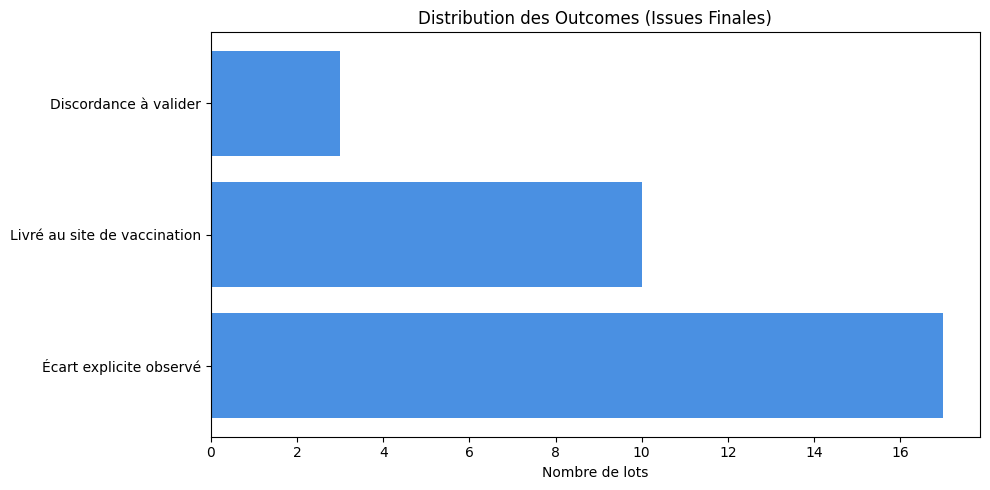

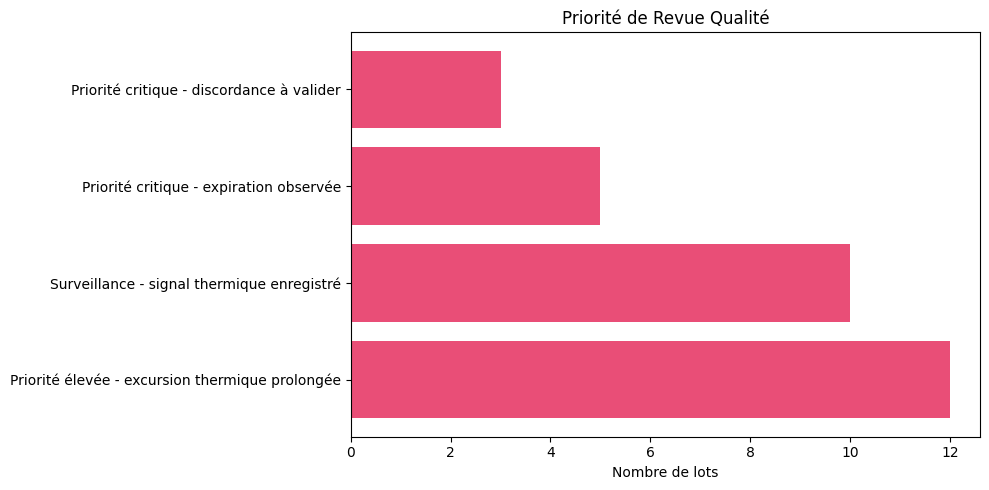

In [570]:
# Graphique 1 : Outcome (Issue finale)
plt.figure(figsize=(10, 5))
outcome_counts = batch_dashboard['issue_finale_observee'].value_counts()
plt.barh(outcome_counts.index, outcome_counts.values, color='#4A90E2')
plt.title('Distribution des Outcomes (Issues Finales)')
plt.xlabel('Nombre de lots')
plt.tight_layout()
plt.show()

# Graphique 2 : Priorité (Niveau de revue qualité)
plt.figure(figsize=(10, 5))
priority_counts = batch_dashboard['niveau_revue_qualite'].value_counts()
plt.barh(priority_counts.index, priority_counts.values, color='#E94E77')
plt.title('Priorité de Revue Qualité')
plt.xlabel('Nombre de lots')
plt.tight_layout()
plt.show()

Nombre d'observations pour batch007 : 154


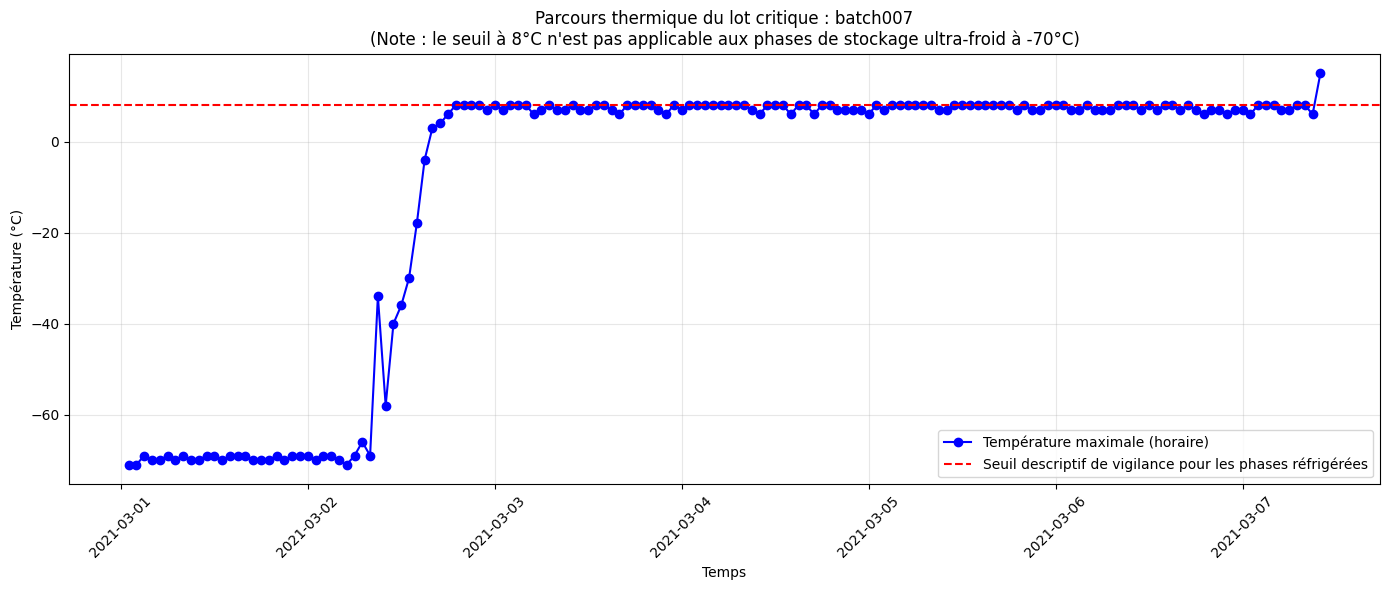

In [571]:
# Analyse détaillée d'un lot critique
selected_batch = "batch007"

batch_timeline = (
    hourly_data[hourly_data["batch_id"] == selected_batch]
    .sort_values("datetime")
)

print("Nombre d'observations pour", selected_batch, ":", len(batch_timeline))

plt.figure(figsize=(14, 6))
plt.plot(batch_timeline["datetime"], batch_timeline["temperature_max"], marker='o', linestyle='-', color='b', label="Température maximale (horaire)")

# Ligne de référence à 8°C pour les phases réfrigérées
plt.axhline(y=8, color='r', linestyle='--', label="Seuil descriptif de vigilance pour les phases réfrigérées")

plt.title(f"Parcours thermique du lot critique : {selected_batch}\n(Note : le seuil à 8°C n'est pas applicable aux phases de stockage ultra-froid à -70°C)")
plt.xlabel("Temps")
plt.ylabel("Température (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


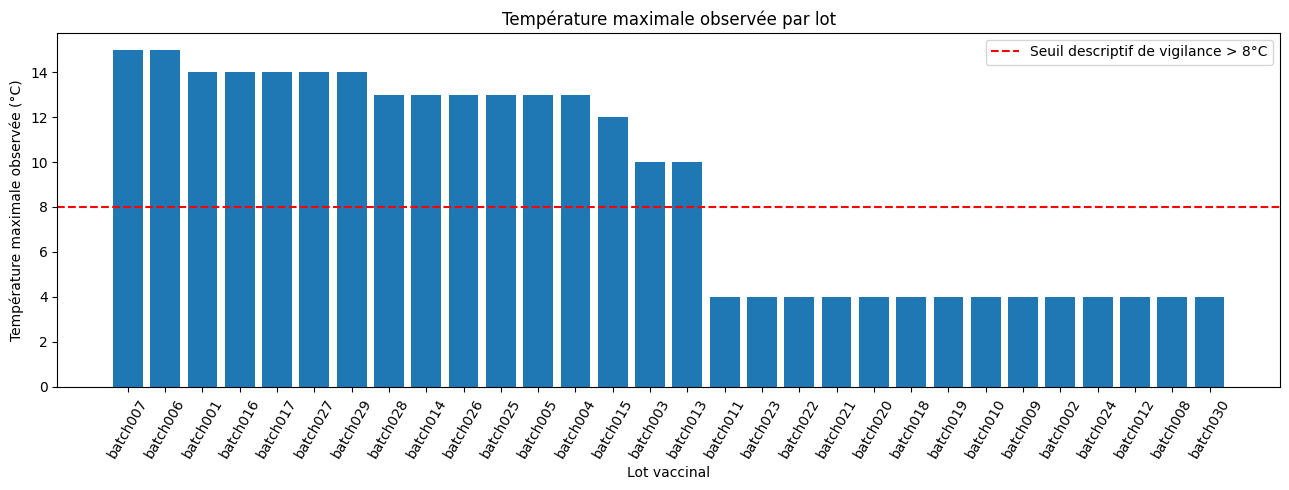

In [572]:
# Température maximale par lot selon l'issue finale

plot_data = batch_dashboard.sort_values(
    by="temperature_max",
    ascending=False
)

plt.figure(figsize=(13, 5))
plt.bar(
    plot_data["batch_id"],
    plot_data["temperature_max"]
)

plt.axhline(
    y=8,
    color="red",
    linestyle="--",
    label="Seuil descriptif de vigilance > 8°C"
)

plt.title("Température maximale observée par lot")
plt.xlabel("Lot vaccinal")
plt.ylabel("Température maximale observée (°C)")
plt.xticks(rotation=60)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Contexte Méthodologique
Ce dataset est international et contient des localisations comme les États-Unis ou l'Inde.
Il est crucial de préciser que :
- Le dataset ne représente en aucun cas les opérations réelles de la chaîne du froid dans le Souss-Massa.
- Souss-Massa est le contexte cible futur pour l'adaptation de ce prototype.
- Ce notebook valide une architecture analytique et un système d'aide à la décision.
- Il n'établit aucune conclusion sur le système de santé marocain réel.

Le dataset contient des températures très variées (ultra-low ~ -70°C, réfrigéré 2°C–8°C, et température ambiante).
Par conséquent :
- Nous n'appliquons jamais une règle universelle de conformité 2°C–8°C à tous les relevés.
- Nous n'affirmons jamais qu'une température est anormale sans considérer son contexte logistique.
- Le seuil de 8°C est utilisé uniquement comme un **Seuil descriptif de vigilance pour les phases réfrigérées**.

# Détection d’anomalies thermiques contextuelles
Ce module vise à identifier automatiquement les profils thermiques atypiques nécessitant une revue qualité. Les profils horaires atypiques signalés constituent des signaux d’aide à l’analyse et ne représentent ni une cause officielle d'un écart observé, ni une décision réglementaire automatique.

In [573]:
# C1 & C2. Préparation du dataset pour la détection de profils atypiques (sans leakage)
import pandas as pd
import numpy as np

# Exclusion de TOUTES les phases terminales (livrées ou écarts explicites observés) pour ne conserver que
# le tronc commun du parcours (source_hub, air_transit, etc.).
# Cela permet d'évaluer équitablement si un profil thermique atypique s'est
# manifesté "avant" que le lot n'atteigne sa destination finale.

# Inclusion exclusive du tronc commun
tronc_commun_anomalie = [
    "source_hub",
    "source_air_cargo",
    "source_reefer_truck",
    "air_transit",
    "dest_air_cargo"
]
anomaly_hourly_data = hourly_data[hourly_data['current_hop_clean'].isin(tronc_commun_anomalie)].copy()
print(f'Observations avant exclusion des écart explicite observés : {len(hourly_data)}')
print(f'Observations après exclusion des écart explicite observés : {len(anomaly_hourly_data)}')

# Création des variables (Feature Engineering)
anomaly_hourly_data['temperature_range'] = anomaly_hourly_data['temperature_max'] - anomaly_hourly_data['temperature_min']

# Variables temporelles par lot
anomaly_hourly_data = anomaly_hourly_data.sort_values(['batch_id', 'datetime'])
anomaly_hourly_data['temperature_change_from_previous_hour'] = anomaly_hourly_data.groupby('batch_id')['temperature_max'].diff().fillna(0)

anomaly_hourly_data['temperature_max_rolling_mean_3h'] = anomaly_hourly_data.groupby('batch_id')['temperature_max'].transform(lambda x: x.rolling(3, min_periods=1).mean())
anomaly_hourly_data['temperature_max_rolling_std_3h'] = anomaly_hourly_data.groupby('batch_id')['temperature_max'].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0))
anomaly_hourly_data['temperature_deviation_from_rolling_mean'] = anomaly_hourly_data['temperature_max'] - anomaly_hourly_data['temperature_max_rolling_mean_3h']

# Variables contextuelles (médiane calculée dynamiquement par phase et stockage)
anomaly_hourly_data['context_group'] = anomaly_hourly_data['current_hop_clean'] + "_" + anomaly_hourly_data['external_storage_clean']
storage_medians = anomaly_hourly_data.groupby('context_group')['temperature_max'].median().to_dict()
anomaly_hourly_data['storage_median'] = anomaly_hourly_data['context_group'].map(storage_medians)
anomaly_hourly_data['deviation_from_storage_median'] = anomaly_hourly_data['temperature_max'] - anomaly_hourly_data['storage_median']
anomaly_hourly_data['absolute_deviation_from_storage_median'] = anomaly_hourly_data['deviation_from_storage_median'].abs()

# Encodage One-Hot des contextes logistiques
logistics_encoded = pd.get_dummies(anomaly_hourly_data[['current_hop_clean', 'external_storage_clean']], drop_first=False)
anomaly_hourly_data = pd.concat([anomaly_hourly_data, logistics_encoded], axis=1)

Observations avant exclusion des écart explicite observés : 13337
Observations après exclusion des écart explicite observés : 1906


### C3. Analyse exploratoire visuelle avant modélisation

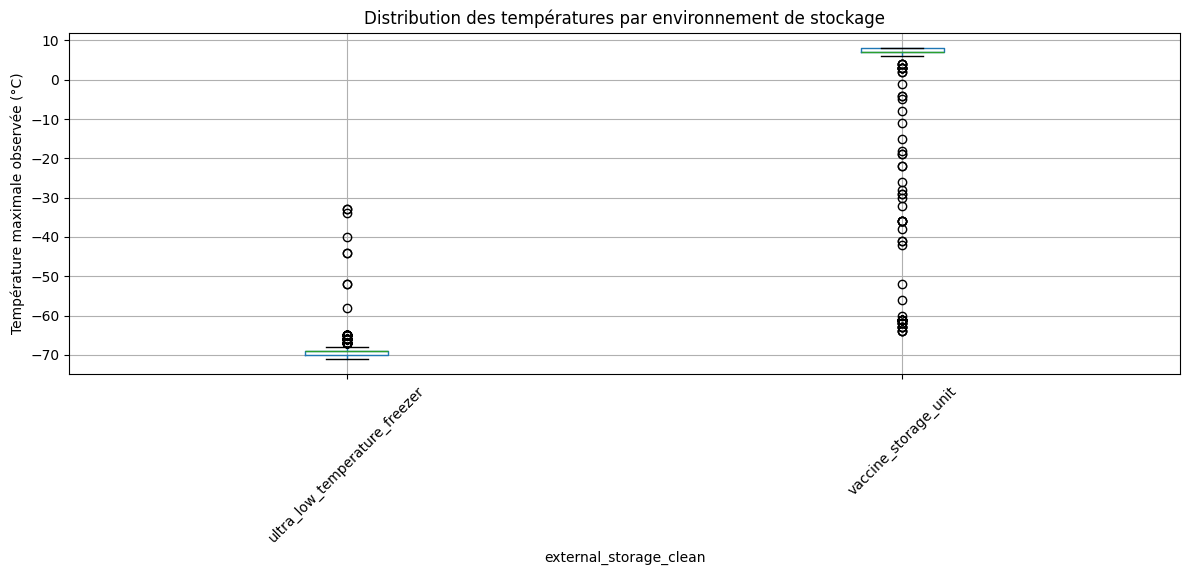

In [574]:
import matplotlib.pyplot as plt

ax = anomaly_hourly_data.boxplot(
    column="temperature_max",
    by="external_storage_clean",
    figsize=(12, 6),
    rot=45
)

plt.title("Distribution des températures par environnement de stockage")
plt.suptitle("")
plt.ylabel("Température maximale observée (°C)")
plt.tight_layout()
plt.show()


### C4. Modélisation : Isolation Forest
Nous utilisons l'Isolation Forest car il n'existe pas de label officiel d'anomalie validé. Ce modèle ne prédit pas un écart explicite observé, il priorise les observations thermiques inhabituelles pour une revue humaine.

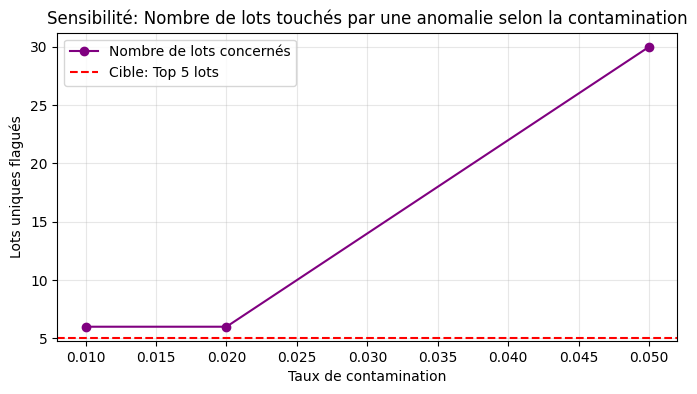

In [575]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

features = [
    'temperature_min', 'temperature_max', 'temperature_moyenne', 'temperature_range',
    'humidite_moyenne', 'temperature_change_from_previous_hour', 
    'temperature_max_rolling_mean_3h', 'temperature_max_rolling_std_3h', 
    'temperature_deviation_from_rolling_mean', 'deviation_from_storage_median', 
    'absolute_deviation_from_storage_median'
]

X = anomaly_hourly_data[features].copy()

# Analyse de sensibilité de la contamination
contaminations = [0.01, 0.02, 0.05]
lots_flagged = []
profiles_flagged = []
for c in contaminations:
    iso = IsolationForest(contamination=c, random_state=42)
    preds = iso.fit_predict(X)
    flagged_batches = anomaly_hourly_data[preds == -1]['batch_id'].nunique()
    flagged_profiles = (preds == -1).sum()
    lots_flagged.append(flagged_batches)
    profiles_flagged.append(flagged_profiles)

plt.figure(figsize=(8, 4))
plt.plot(contaminations, lots_flagged, marker='o', color='purple', label='Nombre de lots concernés')
plt.axhline(y=5, color='red', linestyle='--', label='Cible: Top 5 lots')
plt.title('Sensibilité: Nombre de lots touchés par une anomalie selon la contamination')
plt.xlabel('Taux de contamination')
plt.ylabel('Lots uniques flagués')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
anomaly_sensitivity_df = pd.DataFrame({'contamination': contaminations, 'nombre_profils_signales': profiles_flagged, 'nombre_lots_concernes': lots_flagged})

# Entraînement final avec un modèle de base (score universel)
iso_forest = IsolationForest(contamination=0.02, random_state=42)
preds = iso_forest.fit_predict(X)
anomaly_hourly_data['iso_forest_pred'] = preds
# On utilise le score continu pour prioriser plutôt que le booléen binaire
anomaly_hourly_data['anomaly_score'] = -iso_forest.decision_function(X)

In [576]:
# C5. Résultats du modèle et priorisation des profils atypiques

# Résultat brut du modèle Isolation Forest
anomaly_hourly_data["is_model_flagged"] = (
    anomaly_hourly_data["iso_forest_pred"] == -1
)

model_flagged_observations = anomaly_hourly_data[
    anomaly_hourly_data["is_model_flagged"]
].copy()

# Résumé des observations réellement signalées par le modèle
anomaly_batch_summary = (
    model_flagged_observations
    .groupby("batch_id")
    .agg(
        nombre_profils_signales=("is_model_flagged", "sum"),
        anomaly_score_max=("anomaly_score", "max"),
        temperature_max_signalee=("temperature_max", "max"),
        deviation_contextuelle_max=("absolute_deviation_from_storage_median", "max"),
        premiere_observation_signalee=("datetime", "min"),
        derniere_observation_signalee=("datetime", "max")
    )
    .reset_index()
)

# Ajout des issues finales uniquement après scoring, pour interprétation
anomaly_batch_summary = anomaly_batch_summary.merge(
    batch_dashboard[[
        "batch_id",
        "issue_finale_observee",
        "niveau_revue_qualite"
    ]],
    on="batch_id",
    how="left"
)

# Classement métier des lots signalés selon leur score maximal
anomaly_batch_summary = anomaly_batch_summary.sort_values(
    "anomaly_score_max",
    ascending=False
).reset_index(drop=True)

anomaly_batch_summary["rang_priorite"] = (
    anomaly_batch_summary.index + 1
)

anomaly_batch_summary["is_top_5_priority"] = (
    anomaly_batch_summary["rang_priorite"] <= 5
)

# Table séparée pour affichage Top 5 dans le dashboard
top_5_priority_batches = anomaly_batch_summary[
    anomaly_batch_summary["is_top_5_priority"]
].copy()

print("Profils horaires analysés :", len(anomaly_hourly_data))
print("Profils signalés par Isolation Forest :", len(model_flagged_observations))
print("Lots contenant au moins un profil signalé :", anomaly_batch_summary["batch_id"].nunique())

display(anomaly_batch_summary)
display(top_5_priority_batches)


Profils horaires analysés : 1906
Profils signalés par Isolation Forest : 39
Lots contenant au moins un profil signalé : 6


,batch_id,nombre_profils_signales,anomaly_score_max,temperature_max_signalee,deviation_contextuelle_max,premiere_observation_signalee,derniere_observation_signalee,issue_finale_observee,niveau_revue_qualite,rang_priorite,is_top_5_priority
0,batch013,6,0.054179,4,36.0,2020-11-02 09:00:00,2020-11-02 16:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,1,True
1,batch007,6,0.052629,3,43.0,2021-03-02 09:00:00,2021-03-02 16:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,2,True
2,batch029,8,0.052629,2,43.0,2021-08-02 09:00:00,2021-08-02 16:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,3,True
3,batch004,6,0.051948,-1,63.0,2020-12-02 14:00:00,2020-12-02 19:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,4,True
4,batch026,6,0.045273,3,49.0,2021-08-02 15:00:00,2021-08-02 20:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,5,True
5,batch016,7,0.043740,3,59.0,2021-02-02 14:00:00,2021-02-02 20:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,6,False


,batch_id,nombre_profils_signales,anomaly_score_max,temperature_max_signalee,deviation_contextuelle_max,premiere_observation_signalee,derniere_observation_signalee,issue_finale_observee,niveau_revue_qualite,rang_priorite,is_top_5_priority
0,batch013,6,0.054179,4,36.0,2020-11-02 09:00:00,2020-11-02 16:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,1,True
1,batch007,6,0.052629,3,43.0,2021-03-02 09:00:00,2021-03-02 16:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,2,True
2,batch029,8,0.052629,2,43.0,2021-08-02 09:00:00,2021-08-02 16:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,3,True
3,batch004,6,0.051948,-1,63.0,2020-12-02 14:00:00,2020-12-02 19:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,4,True
4,batch026,6,0.045273,3,49.0,2021-08-02 15:00:00,2021-08-02 20:00:00,Écart explicite observé,Priorité élevée - excursion thermique prolongée,5,True


In [577]:
anomaly_kpis = pd.DataFrame({
    "KPI": [
        "Profils horaires analysés",
        "Profils signalés par Isolation Forest",
        "Lots contenant au moins un profil signalé",
        "Lots signalés avec écart explicite observé",
        "Lots signalés livrés au site",
        "Lots signalés avec discordance à valider",
        "Lots affichés dans le Top 5 prioritaire"
    ],
    "Valeur": [
        len(anomaly_hourly_data),
        len(model_flagged_observations),
        anomaly_batch_summary["batch_id"].nunique(),
        (
            anomaly_batch_summary["issue_finale_observee"]
            == "Écart explicite observé"
        ).sum(),
        (
            anomaly_batch_summary["issue_finale_observee"]
            == "Livré au site de vaccination"
        ).sum(),
        (
            anomaly_batch_summary["issue_finale_observee"]
            == "Discordance à valider"
        ).sum(),
        len(top_5_priority_batches)
    ]
})

display(anomaly_kpis)


,KPI,Valeur
0,Profils horaires analysés,1906
1,Profils signalés par Isolation Forest,39
2,Lots contenant au moins un profil signalé,6
3,Lots signalés avec écart explicite observé,6
4,Lots signalés livrés au site,0
5,Lots signalés avec discordance à valider,0
6,Lots affichés dans le Top 5 prioritaire,5


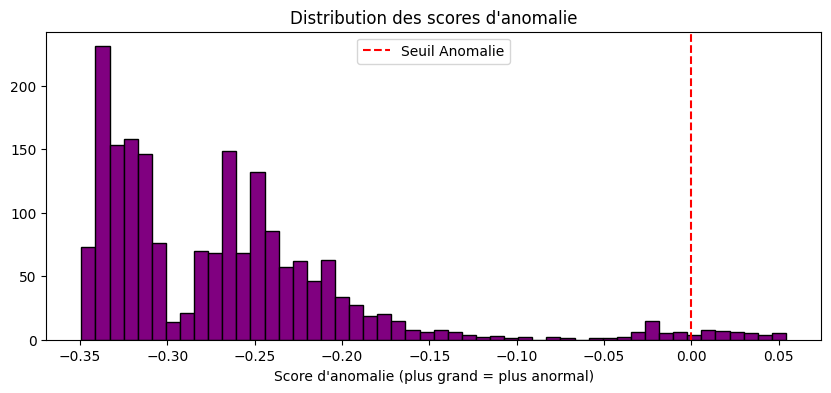

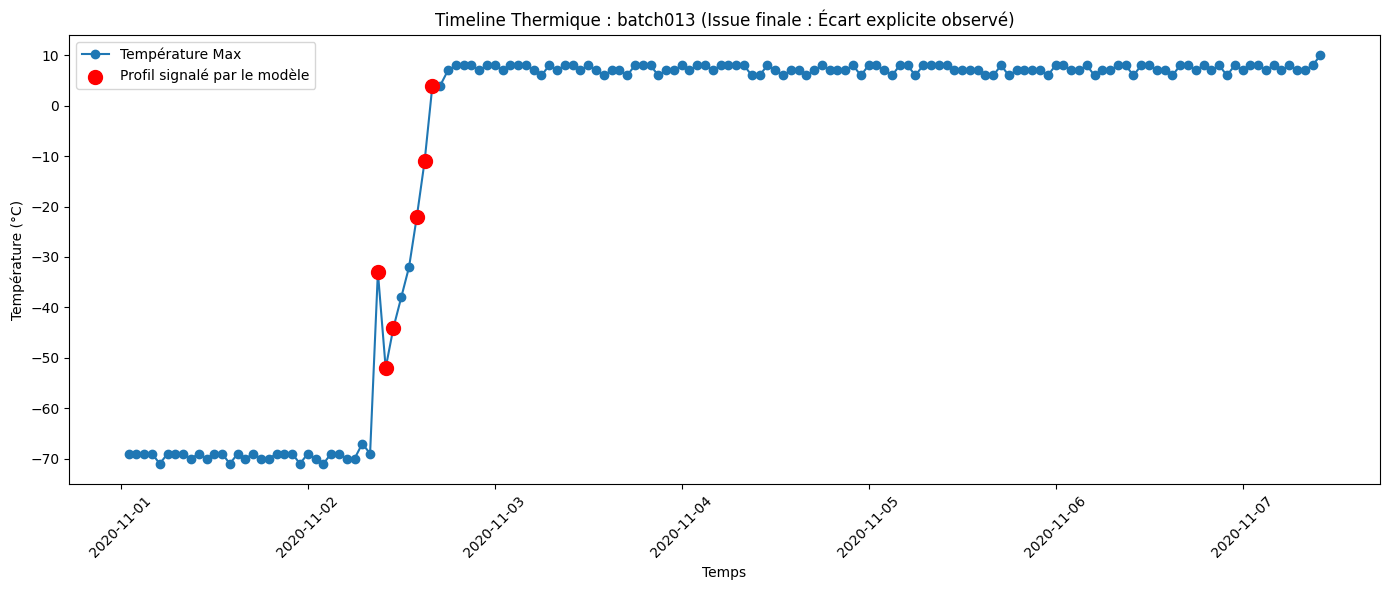

In [578]:
# C6. Visualisations des anomalies

plt.figure(figsize=(10, 4))
plt.hist(anomaly_hourly_data['anomaly_score'], bins=50, color='purple', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Seuil Anomalie')
plt.title('Distribution des scores d\'anomalie')
plt.xlabel('Score d\'anomalie (plus grand = plus anormal)')
plt.legend()
plt.show()

if not model_flagged_observations.empty:
    top_batch = model_flagged_observations.nlargest(1, 'anomaly_score')['batch_id'].values[0]
    
    batch_timeline = hourly_data[hourly_data['batch_id'] == top_batch].sort_values('datetime')
    batch_anomalies = model_flagged_observations[model_flagged_observations['batch_id'] == top_batch]
    
    plt.figure(figsize=(14, 6))
    plt.plot(batch_timeline['datetime'], batch_timeline['temperature_max'], marker='o', label='Température Max')
    plt.scatter(batch_anomalies['datetime'], batch_anomalies['temperature_max'], color='red', s=100, label='Profil signalé par le modèle', zorder=5)
    
    outcome = batch_dashboard.loc[batch_dashboard['batch_id'] == top_batch, 'issue_finale_observee'].values[0]
    plt.title(f'Timeline Thermique : {top_batch} (Issue finale : {outcome})')
    plt.xlabel('Temps')
    plt.ylabel('Température (°C)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### C7. Interprétation des anomalies
L'approche d'Isolation Forest a permis d'isoler des profils horaires atypiques basés sur le contexte logistique (environnement, ruptures soudaines).
Ces anomalies ne constituent en aucun cas une cause officielle d'un écart observé, mais servent à alerter les réviseurs dans le dashboard (par exemple, pour afficher un indicateur 'Signal à examiner' ou 'Revue qualité requise').

# Classification exploratoire des issues observées
La classification exploratoire vise à comprendre les signaux associés aux issues observées dans le dataset. En raison du nombre limité de lots et de l’absence d’un motif officiel de écart explicite observé, les résultats ne doivent pas être interprétés comme un modèle de décision réglementaire ou comme un outil permettant d’automatiser le écart explicite observé d’un lot vaccinal.

In [579]:
# D1 & D2. Préparation des données de classification sans leakage
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


valid_outcomes = ['Livré au site de vaccination', 'Écart explicite observé']
classification_batches = batch_dashboard[batch_dashboard['issue_finale_observee'].isin(valid_outcomes)]

print(f'Nombre total de lots : {len(batch_dashboard)}')
print(f'Nombre de lots exclus (discordance/incertains) : {len(batch_dashboard) - len(classification_batches)}')
print(f'Nombre de lots pour classification : {len(classification_batches)}')

# Construction des features pré-outcome à partir des données excluant les terminaux de écart explicite observé et d'immunisation
tronc_commun = [
    "source_hub",
    "source_air_cargo",
    "source_reefer_truck",
    "air_transit",
    "dest_air_cargo"
]
pre_outcome_data = hourly_data[hourly_data['current_hop_clean'].isin(tronc_commun)]

pre_features = pre_outcome_data.groupby('batch_id').agg(
    pre_temperature_max=('temperature_max', 'max'),
    pre_temperature_moyenne=('temperature_moyenne', 'mean'),
    pre_heures_hors_limite_max=('out_of_bound_temperature_hours_max', 'max'),
    pre_heures_ultra_low_max=('ultra_low_temperature_freezer_hours_max', 'max'),
    pre_heures_refrigeration_max=('refrigeration_temperature_hours_max', 'max'),
    pre_expiration_min=('item_expiry_hours_min', 'min'),
    pre_humidite_moyenne=('humidite_moyenne', 'mean'),
    pre_nombre_localisations=('location', 'nunique'),
    pre_nombre_transitions_stockage=('external_storage_clean', 'nunique')
).reset_index()

classification_data = classification_batches[['batch_id', 'issue_finale_observee']].merge(pre_features, on='batch_id', how='inner')
classification_data['target'] = (classification_data['issue_finale_observee'] == 'Écart explicite observé').astype(int)

print('Distribution de la cible (0: Livré, 1: Écart) :')
print(classification_data['target'].value_counts())

Nombre total de lots : 30
Nombre de lots exclus (discordance/incertains) : 3
Nombre de lots pour classification : 27
Distribution de la cible (0: Livré, 1: Écart) :
target
1    17
0    10
Name: count, dtype: int64


### D3. Analyse exploratoire avant classification

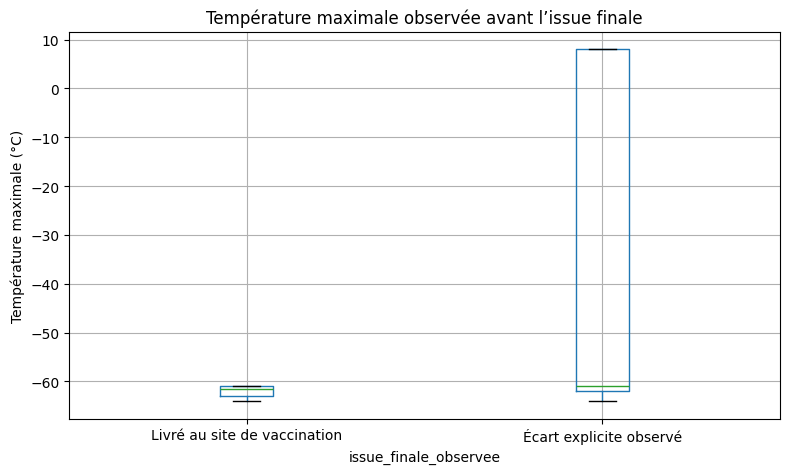

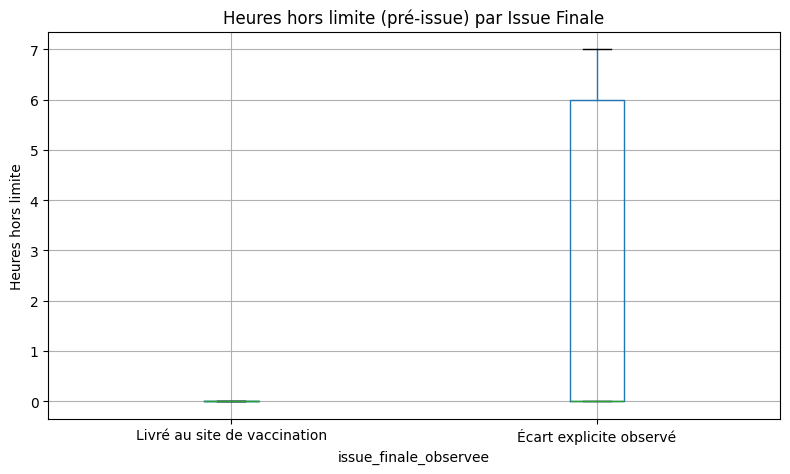

In [580]:
ax = classification_data.boxplot(
    column="pre_temperature_max",
    by="issue_finale_observee",
    figsize=(8, 5)
)
plt.title("Température maximale observée avant l’issue finale")
plt.suptitle("")
plt.ylabel("Température maximale (°C)")
plt.tight_layout()
plt.show()

ax = classification_data.boxplot(
    column="pre_heures_hors_limite_max",
    by="issue_finale_observee",
    figsize=(8, 5)
)
plt.title("Heures hors limite (pré-issue) par Issue Finale")
plt.suptitle("")
plt.ylabel("Heures hors limite")
plt.tight_layout()
plt.show()

In [581]:
# D4. Modélisation via LeaveOneOut
X_clf = classification_data[['pre_temperature_max', 'pre_temperature_moyenne', 'pre_heures_hors_limite_max', 'pre_humidite_moyenne']]
y_clf = classification_data['target']

loo = LeaveOneOut()

lr_preds = np.zeros(len(y_clf))
dt_preds = np.zeros(len(y_clf))

lr = LogisticRegression(random_state=42)
scaler = StandardScaler()
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

for train_index, test_index in loo.split(X_clf):
    X_train, X_test = X_clf.iloc[train_index], X_clf.iloc[test_index]
    y_train = y_clf.iloc[train_index]
    
    # Scale for LR
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr.fit(X_train_scaled, y_train)
    lr_preds[test_index] = lr.predict(X_test_scaled)
    
    dt.fit(X_train, y_train)
    dt_preds[test_index] = dt.predict(X_test)

# Metrics
def get_metrics(y_true, y_pred, name):
    return {
        'model_name': name,
        'evaluation_method': 'LeaveOneOut',
        'number_of_batches': len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'methodological_warning': 'Échantillon extrêmement faible, résultats exploratoires uniquement.'
    }

metrics_lr = get_metrics(y_clf, lr_preds, 'Logistic Regression (Scaled)')
metrics_dt = get_metrics(y_clf, dt_preds, 'Decision Tree (max_depth=3)')
classification_metrics = pd.DataFrame([metrics_lr, metrics_dt])

display(classification_metrics)

,model_name,evaluation_method,number_of_batches,accuracy,balanced_accuracy,precision,recall,f1,methodological_warning
0,Logistic Regression (Scaled),LeaveOneOut,27,0.592593,0.470588,0.615385,0.941176,0.744186,"Échantillon extrêmement faible, résultats exploratoires uniquement."
1,Decision Tree (max_depth=3),LeaveOneOut,27,0.740741,0.752941,0.857143,0.705882,0.774194,"Échantillon extrêmement faible, résultats exploratoires uniquement."


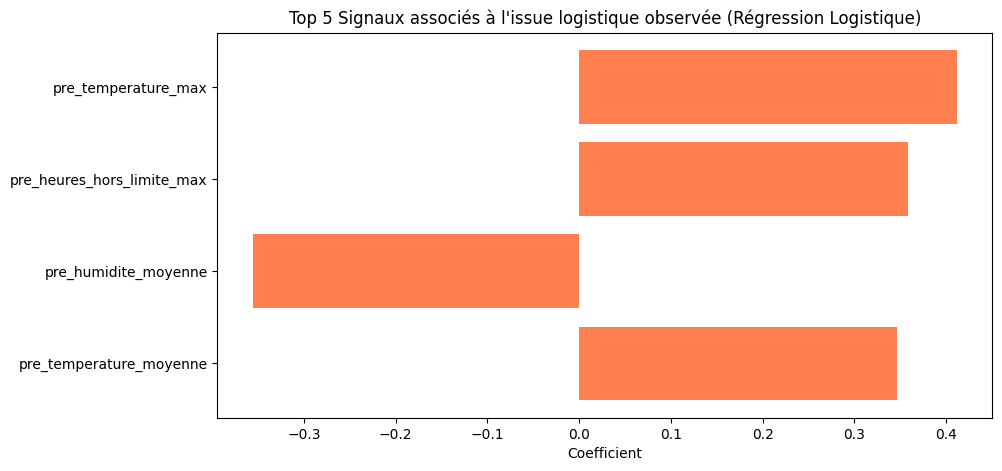

In [582]:
# D5. Interprétabilité
# Refit on full dataset to inspect feature importance
X_scaled_full = scaler.fit_transform(X_clf)
lr.fit(X_scaled_full, y_clf)
dt.fit(X_clf, y_clf)

feature_names = X_clf.columns

lr_importance = pd.DataFrame({
    'model_name': 'Logistic Regression',
    'feature': feature_names,
    'importance_or_coefficient': lr.coef_[0],
    'absolute_importance': np.abs(lr.coef_[0]),
    'interpretation_type': 'coefficient'
}).sort_values('absolute_importance', ascending=False)

dt_importance = pd.DataFrame({
    'model_name': 'Decision Tree',
    'feature': feature_names,
    'importance_or_coefficient': dt.feature_importances_,
    'absolute_importance': dt.feature_importances_,
    'interpretation_type': 'gini_importance'
}).sort_values('absolute_importance', ascending=False)

classification_feature_importance = pd.concat([lr_importance, dt_importance])

plt.figure(figsize=(10, 5))
plt.barh(lr_importance['feature'][:5], lr_importance['importance_or_coefficient'][:5], color='coral')
plt.title("Top 5 Signaux associés à l'issue logistique observée (Régression Logistique)")
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()
plt.show()

### D6. Limites méthodologiques
- Échantillon total de seulement 30 lots, dont encore moins utilisables pour la classification.
- La cible représente une issue observée et non une décision réglementaire parfaitement documentée.
- Les métriques obtenues sont purement exploratoires et ne démontrent aucune aptitude à un déploiement réel en l'état.
- Des données locales supplémentaires (Souss-Massa) et des motifs d'exclusion formels sont nécessaires pour valider un modèle d'IA de bout en bout.

In [583]:
classification_predictions_exploratory = classification_data[['batch_id', 'issue_finale_observee', 'target']].copy()
classification_predictions_exploratory['logistic_regression_oof_prediction'] = lr_preds
classification_predictions_exploratory['decision_tree_oof_prediction'] = dt_preds
classification_predictions_exploratory['disclaimer'] = 'Exploratoire et non-réglementaire'

In [584]:
import os
is_kaggle = os.path.exists('/kaggle/working')
output_dir = '/kaggle/working/' if is_kaggle else './outputs/'
os.makedirs(output_dir, exist_ok=True)

export_paths = {
    "coldmed_data_clean.csv": df_clean,
    "coldmed_batch_summary.csv": batch_summary,
    "coldmed_batch_dashboard_corrige.csv": batch_dashboard,
    "coldmed_final_state_corrige.csv": final_state,
    "coldmed_kpis_dashboard_corrige.csv": kpis_dashboard,
    "coldmed_lots_a_valider.csv": lots_a_valider,
    "coldmed_anomaly_scores.csv": anomaly_hourly_data,
    "coldmed_anomaly_flagged_observations.csv": model_flagged_observations,
    "coldmed_anomaly_batch_summary.csv": anomaly_batch_summary,
    "coldmed_anomaly_top5_priority.csv": top_5_priority_batches,
    "coldmed_anomaly_kpis.csv": anomaly_kpis,
    "coldmed_anomaly_sensitivity.csv": anomaly_sensitivity_df,
    "coldmed_classification_dataset_pre_outcome.csv": classification_data,
    "coldmed_classification_model_metrics.csv": classification_metrics,
    "coldmed_classification_feature_importance.csv": classification_feature_importance,
    "coldmed_classification_predictions_exploratory.csv": classification_predictions_exploratory
}

print('Résumé des exports :')
for filename, df_export in export_paths.items():
    path = f'{output_dir}{filename}'
    df_export.to_csv(path, index=False, encoding='utf-8-sig')
    print(f'- {filename} : {len(df_export)} lignes')

Résumé des exports :
- coldmed_data_clean.csv : 26373 lignes
- coldmed_batch_summary.csv : 30 lignes
- coldmed_batch_dashboard_corrige.csv : 30 lignes
- coldmed_final_state_corrige.csv : 30 lignes
- coldmed_kpis_dashboard_corrige.csv : 7 lignes
- coldmed_lots_a_valider.csv : 3 lignes
- coldmed_anomaly_scores.csv : 1906 lignes
- coldmed_anomaly_flagged_observations.csv : 39 lignes
- coldmed_anomaly_batch_summary.csv : 6 lignes
- coldmed_anomaly_top5_priority.csv : 5 lignes
- coldmed_anomaly_kpis.csv : 7 lignes
- coldmed_anomaly_sensitivity.csv : 3 lignes
- coldmed_classification_dataset_pre_outcome.csv : 27 lignes
- coldmed_classification_model_metrics.csv : 2 lignes
- coldmed_classification_feature_importance.csv : 8 lignes
- coldmed_classification_predictions_exploratory.csv : 27 lignes
